# Kerala crop prices — Phase 1 EDA

Which crop × market series are good enough to model? Data: `prices_raw` (Agmarknet,
Rs./quintal, validated), backfilled from 2018 plus the daily pull.

**Usable series rule:** span ≥ 2 years, < 20 % missing *trading* days (Mon–Sat; Kerala
mandis rarely trade on Sundays, so calendar-day gaps would overstate missingness), and
still alive (last observation ≤ 30 days before the latest date in the table).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from cropcast.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160, "display.max_columns", 20, "display.max_rows", 80)

# Categorical palette (validated, fixed order): one hue per crop, never re-ordered.
CROP_COLORS = {"banana": "#2a78d6", "coconut": "#eb6834", "rubber": "#1baf7a",
               "pepper": "#eda100", "tapioca": "#e87ba4"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.axisbelow": True, "lines.linewidth": 1.2, "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False,
})

eng = get_engine()
df = pd.read_sql(text("SELECT date, district, market, commodity, variety, min_price, "
                      "max_price, modal_price, source FROM prices_raw"), eng,
                 parse_dates=["date"])
for c in ("min_price", "max_price", "modal_price"):
    df[c] = df[c].astype(float)
LATEST = df["date"].max()
print(f"{len(df):,} rows | {df.date.min():%Y-%m-%d} → {LATEST:%Y-%m-%d} | "
      f"{df.market.nunique()} markets | sources: {df.source.value_counts().to_dict()}")

743,947 rows | 2018-01-01 → 2026-10-03 | 303 markets | sources: {'agmarknet_v2': 743947}


## 1. Volume per crop

In [2]:
summary = (df.groupby("commodity")
             .agg(rows=("modal_price", "size"), first=("date", "min"), last=("date", "max"),
                  markets=("market", "nunique"), varieties=("variety", "nunique"))
             .sort_values("rows", ascending=False))
summary

,rows,first,last,markets,varieties
commodity,,,,,
banana,540607,2018-01-01,2026-10-03,301,20
tapioca,95023,2018-01-01,2026-10-03,159,2
pepper,44400,2018-01-01,2026-10-03,37,6
coconut,43495,2018-01-01,2026-10-03,54,6
rubber,20422,2018-01-01,2026-10-03,18,2


In [3]:
(df.groupby(["commodity", "variety"]).size().rename("rows").reset_index()
   .sort_values(["commodity", "rows"], ascending=[True, False])
   .groupby("commodity").head(6).set_index(["commodity", "variety"]))

rows
commodity variety                    
banana    Nendran              115630
          Palayamthodan         93611
          Green                 70214
          Green Other           58909
          Poovan                58824
          Robusta               46641
coconut   Other                 21634
          Coconut                8359
          Big                    8132
          Medium                 5355
          IISort without Husk      14
          Grade-I                   1
pepper    Other                 18226
          Ungarbled Other       10491
          Ungarbled              6077
          Garbled                4871
          Garbled Other          4238
          Malabar                 497
rubber    Other                 14397
          RSS-4                  6025
tapioca   Other                 50708
          Tapioca               44315

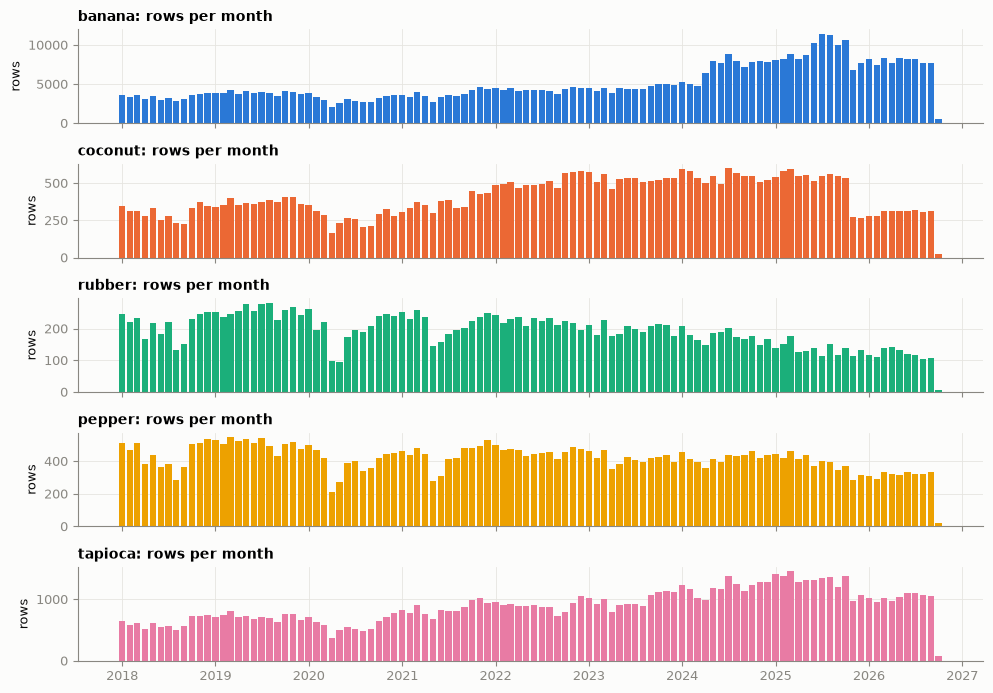

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(10, 7), sharex=True)
for ax, crop in zip(axes, CROP_COLORS):
    m = df[df.commodity == crop].groupby(pd.Grouper(key="date", freq="MS")).size()
    ax.bar(m.index, m.values, width=25, color=CROP_COLORS[crop])
    ax.set_title(f"{crop}: rows per month", loc="left")
    ax.set_ylabel("rows")
fig.tight_layout()

## 2. Coverage matrix

A *series* is (commodity, market, variety): the varieties are different products with
different price levels (Nendran vs Robusta banana differ ~2×), so they must not be pooled.

In [5]:
def trading_days(start, end):
    days = pd.date_range(start, end, freq="D")
    return int((days.dayofweek != 6).sum())   # Mon–Sat

g = df.groupby(["commodity", "market", "variety"])
cov = g.agg(n_days=("date", "nunique"), first=("date", "min"), last=("date", "max"),
            median_price=("modal_price", "median")).reset_index()
cov["span_years"] = (cov["last"] - cov["first"]).dt.days / 365.25
cov["expected"] = [trading_days(a, b) for a, b in zip(cov["first"], cov["last"])]
cov["pct_missing"] = (1 - cov["n_days"] / cov["expected"]).clip(lower=0) * 100
cov["days_since_last"] = (LATEST - cov["last"]).dt.days
cov["usable"] = (cov.span_years >= 2) & (cov.pct_missing < 20) & (cov.days_since_last <= 30)
print(f"{len(cov)} series, {cov.usable.sum()} usable")
cov.groupby("commodity").agg(series=("usable", "size"), usable=("usable", "sum"),
                             best_missing_pct=("pct_missing", "min")).round(1)

1562 series, 90 usable


,series,usable,best_missing_pct
commodity,,,
banana,1189,71,0.0
coconut,70,5,0.0
pepper,61,4,0.0
rubber,28,0,0.0
tapioca,214,10,0.0


In [6]:
def show(d):
    return (d.assign(first=d["first"].dt.date, last=d["last"].dt.date)
             .round({"span_years": 1, "pct_missing": 1, "median_price": 0})
             .drop(columns=["expected"]))

# Top 8 series per crop by coverage (usable ones first).
top = (cov.sort_values(["commodity", "usable", "pct_missing"], ascending=[True, False, True])
          .groupby("commodity").head(8))
show(top).style.apply(
    lambda r: ["background-color: #d9f2e6" if r.usable else ""] * len(r), axis=1
).format(precision=1)

,commodity,market,variety,n_days,first,last,median_price,span_years,pct_missing,days_since_last,usable
175,banana,Chenkal VFPCK,Nendran,826,2024-04-04,2026-10-01,5300.0,2.5,0.0,2,True
371,banana,Kayamkulam,Green Other,2961,2018-01-01,2026-10-03,2400.0,8.8,0.0,0,True
372,banana,Kayamkulam,Nendran,2908,2018-01-01,2026-10-03,3900.0,8.8,0.0,0,True
374,banana,Kayamkulam,Palayamthodan,2921,2018-01-01,2026-10-03,2200.0,8.8,0.0,0,True
644,banana,Mookkannur VFPCK,Nendran,817,2024-04-06,2026-10-03,4300.0,2.5,0.0,0,True
814,banana,Parassala,Nendran,803,2024-04-04,2026-10-03,5500.0,2.5,0.0,0,True
1003,banana,Taliparamba,Other,874,2024-01-26,2026-10-01,6000.0,2.7,0.0,2,True
336,banana,Kannur,Green Other,2725,2018-01-01,2026-10-03,3750.0,8.8,0.6,0,True
1212,coconut,Koduvayoor,Big,1396,2021-12-01,2026-10-03,3800.0,4.8,7.9,0,True
1236,coconut,Palakkad,Coconut,1344,2022-01-01,2026-10-03,3600.0,4.8,9.7,0,True


In [7]:
# Near misses: alive, ≥ 2 years, but 20–40 % missing (candidates if gaps are tolerable).
show(cov[(~cov.usable) & (cov.span_years >= 2) & (cov.days_since_last <= 30)
         & (cov.pct_missing < 40)].sort_values(["commodity", "pct_missing"]))

,commodity,market,variety,n_days,first,last,median_price,span_years,pct_missing,days_since_last,usable
89,banana,Athirampuzha,Green,2191,2018-01-01,2026-10-03,3600.0,8.8,20.1,0,False
123,banana,Broadway,Green,695,2023-12-20,2026-09-30,4700.0,2.8,20.2,3,False
483,banana,Kottayam,Palayamthodan,2186,2018-01-01,2026-10-02,2000.0,8.8,20.2,1,False
484,banana,Kottayam,Poovan,2181,2018-01-01,2026-10-02,5000.0,8.8,20.4,1,False
44,banana,Amballur VFPCK,Nendran,629,2024-03-22,2026-10-02,4800.0,2.5,20.7,1,False
...,...,...,...,...,...,...,...,...,...,...,...
1495,tapioca,Parassala,Tapioca,570,2024-04-09,2026-10-03,2800.0,2.5,26.8,0,False
1539,tapioca,Thrissur,Tapioca,1947,2018-01-03,2026-10-02,2100.0,8.7,28.9,1,False
1520,tapioca,Ranniangadi,Tapioca,1829,2018-01-03,2026-10-03,3000.0,8.7,33.2,0,False
1371,tapioca,Broadway,Other,578,2023-12-19,2026-09-30,3200.0,2.8,33.7,3,False


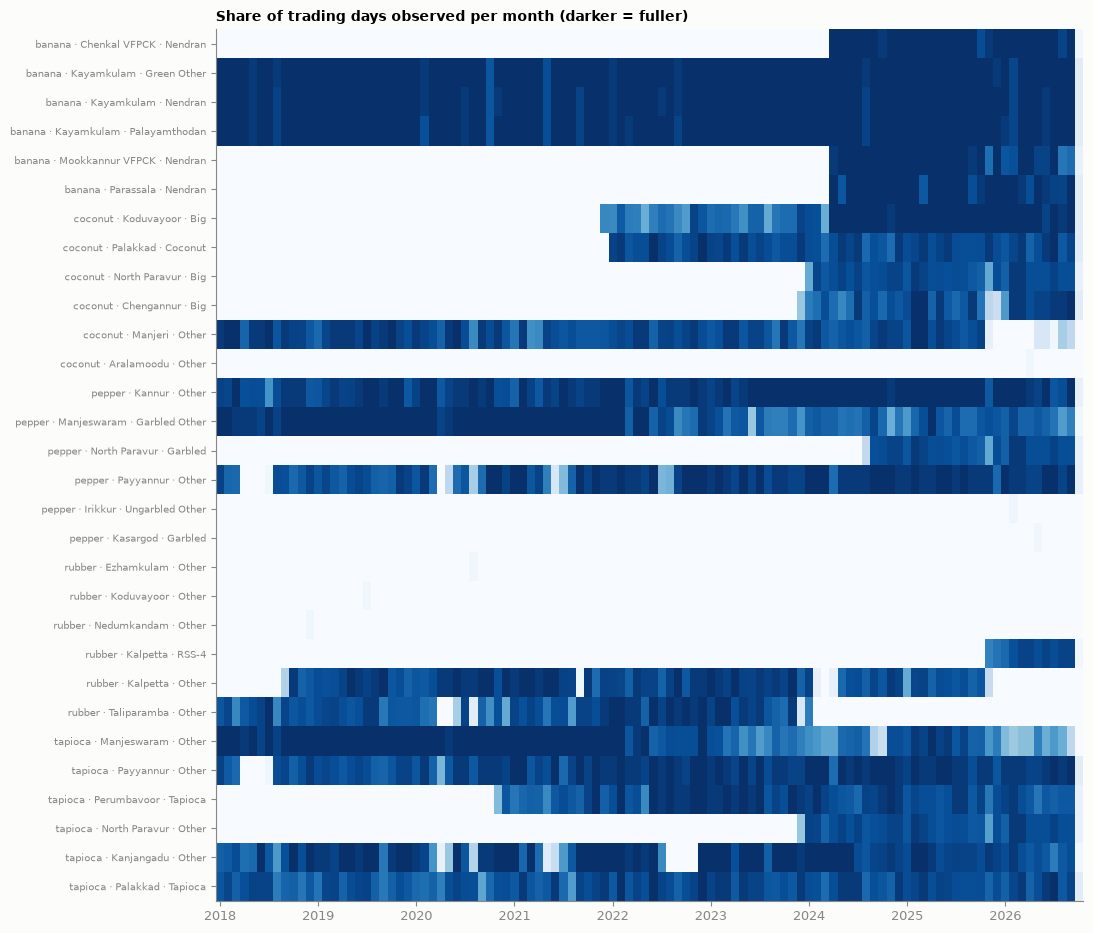

In [8]:
# Heat strip: % of trading days observed per month, best 6 series per crop.
best = (cov.sort_values(["commodity", "usable", "pct_missing"], ascending=[True, False, True])
           .groupby("commodity").head(6))
keys = list(best[["commodity", "market", "variety"]].itertuples(index=False, name=None))
months = pd.date_range(df.date.min().to_period("M").start_time, LATEST, freq="MS")
trade_per_month = pd.Series({m: trading_days(m, m + pd.offsets.MonthEnd(0)) for m in months})
mat = []
for k in keys:
    s = df[(df.commodity == k[0]) & (df.market == k[1]) & (df.variety == k[2])]
    obs = s.groupby(s.date.dt.to_period("M").dt.start_time)["date"].nunique()
    mat.append((obs.reindex(months).fillna(0) / trade_per_month).clip(0, 1).values)
fig, ax = plt.subplots(figsize=(11, 0.28 * len(keys) + 1))
ax.imshow(np.array(mat), aspect="auto", cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(len(keys)), [f"{c} · {m} · {v}" for c, m, v in keys], fontsize=7)
yr = [i for i, m in enumerate(months) if m.month == 1]
ax.set_xticks(yr, [months[i].year for i in yr]); ax.grid(False)
ax.set_title("Share of trading days observed per month (darker = fuller)", loc="left")
fig.tight_layout()

## 3. Price history — best series per crop

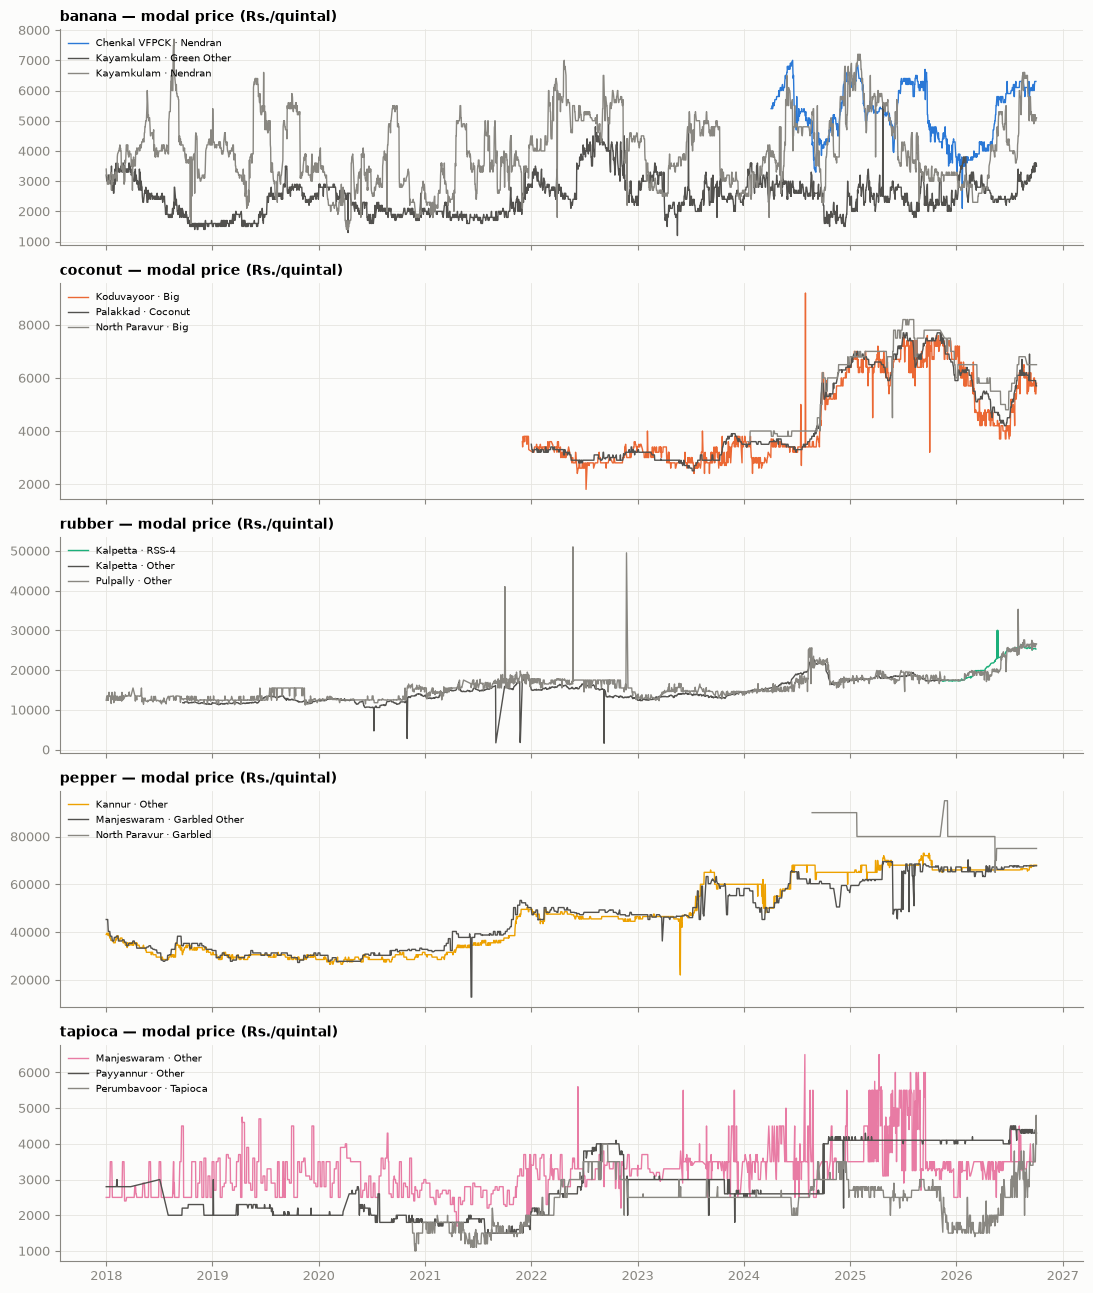

In [9]:
pick = (cov[(cov.n_days > 200) & (cov.days_since_last <= 400)].sort_values(["commodity", "usable", "pct_missing"],
                                         ascending=[True, False, True])
           .groupby("commodity").head(3))
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)
for ax, crop in zip(axes, CROP_COLORS):
    rows = pick[pick.commodity == crop]
    shades = [CROP_COLORS[crop], "#52514e", "#898781"]
    for (_, r), col in zip(rows.iterrows(), shades):
        s = (df[(df.commodity == crop) & (df.market == r.market) & (df.variety == r.variety)]
               .set_index("date")["modal_price"].sort_index())
        ax.plot(s.index, s.values, color=col, lw=1.0, label=f"{r.market} · {r.variety}")
    ax.set_title(f"{crop} — modal price (Rs./quintal)", loc="left")
    ax.legend(loc="upper left", fontsize=7)
fig.tight_layout()

## 4. Seasonality

observations by weekday (Mon=0): {0: 24988, 1: 24614, 2: 24458, 3: 23981, 4: 24384, 5: 21920, 6: 9266}


date,1,2,3,4,5,6,7,8,9,10,11,12
commodity,,,,,,,,,,,,
banana,-4.9,-5.4,-7.1,-3.9,-0.5,5.0,6.3,14.4,9.0,-3.6,-7.6,-4.7
coconut,0.8,0.7,-2.9,-3.1,-7.3,-7.7,-4.6,-2.7,1.4,7.1,10.5,14.5
pepper,-1.6,-3.1,-4.9,-3.0,-2.4,-2.2,-0.5,1.5,3.7,3.2,4.6,5.5
rubber,-8.3,-5.1,-1.6,0.4,-0.5,1.3,3.6,6.0,2.5,-1.2,-1.1,2.6
tapioca,-3.9,-4.9,-3.8,-0.8,-1.7,-0.1,0.4,2.1,4.6,4.9,1.5,2.4


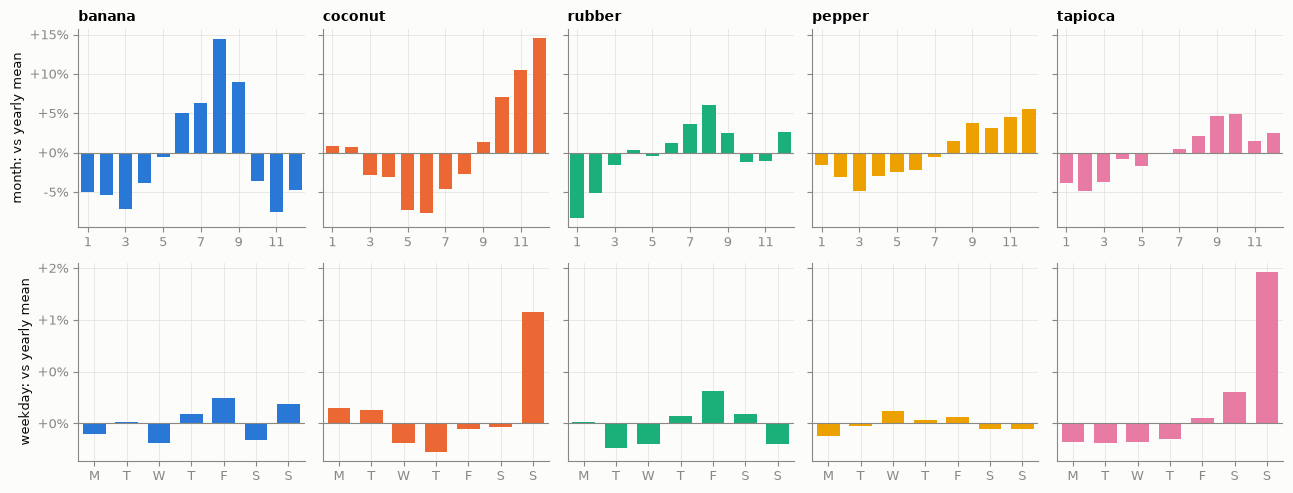

In [10]:
# Month-of-year: price relative to each series' own yearly mean, averaged over usable series
# (falls back to the 5 best-covered series when a crop has none usable).
base = cov[cov.usable]
for crop in CROP_COLORS:
    if (base.commodity == crop).sum() == 0:
        base = pd.concat([base, cov[cov.commodity == crop].nsmallest(5, "pct_missing")])
sel = df.merge(base[["commodity", "market", "variety"]], on=["commodity", "market", "variety"])
sel["year"] = sel.date.dt.year
sel["rel"] = sel.modal_price / sel.groupby(["commodity", "market", "variety", "year"])[
    "modal_price"].transform("mean")
moy = sel.groupby(["commodity", sel.date.dt.month])["rel"].mean().unstack(0)
dow = sel.groupby(["commodity", sel.date.dt.dayofweek])["rel"].mean().unstack(0)
dow_n = sel.groupby(sel.date.dt.dayofweek).size()

fig, axes = plt.subplots(2, 5, figsize=(13, 5), sharey="row")
for i, crop in enumerate(CROP_COLORS):
    axes[0, i].bar(moy.index, moy[crop] - 1, color=CROP_COLORS[crop], width=0.7)
    axes[0, i].axhline(0, color=MUTED, lw=0.8)
    axes[0, i].set_title(crop, loc="left"); axes[0, i].set_xticks(range(1, 13, 2))
    axes[0, i].set_xlim(0.5, 12.5); axes[1, i].set_xlim(-0.5, 6.5)
    axes[1, i].bar(dow.index, dow[crop] - 1, color=CROP_COLORS[crop], width=0.7)
    axes[1, i].axhline(0, color=MUTED, lw=0.8)
    axes[1, i].set_xticks(range(7), list("MTWTFSS"))
axes[0, 0].set_ylabel("month: vs yearly mean")
axes[1, 0].set_ylabel("weekday: vs yearly mean")
axes[0, 0].yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
axes[1, 0].yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
fig.tight_layout()
print("observations by weekday (Mon=0):", dow_n.to_dict())
(moy - 1).mul(100).round(1).T

### Onam / Vishu windows

Festival dates (Thiruvonam; Vishu) are hard-coded here for the EDA only — Phase 2 moves
them to `features/festivals.yaml`. Event study: price relative to the mean of days −45…−22
before the festival, averaged over years and the best-covered series.

,banana,coconut,rubber,pepper,tapioca
Onam peak (-14..0),13.3,5.4,1.2,5.2,5.8
Vishu peak (-14..0),4.8,2.7,1.9,2.7,8.7


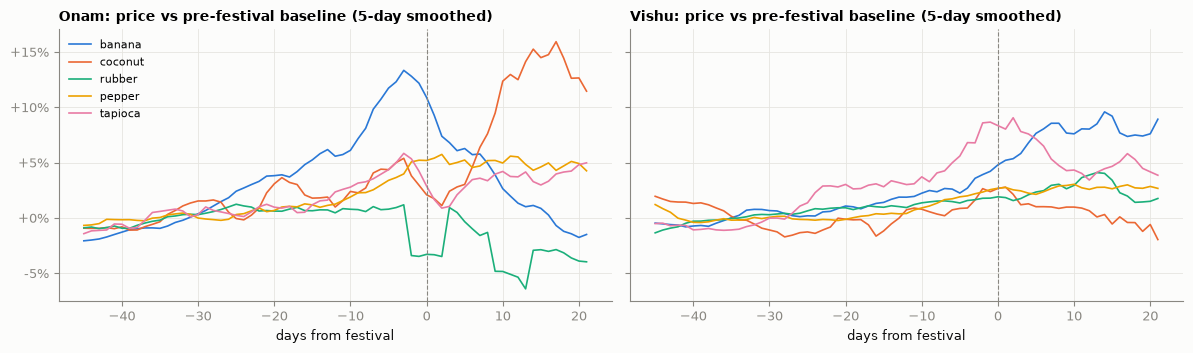

In [11]:
ONAM = ["2018-08-25", "2019-09-11", "2020-08-31", "2021-08-21", "2022-09-08",
        "2023-08-29", "2024-09-15", "2025-09-05", "2026-08-26"]
VISHU = ["2018-04-14", "2019-04-15", "2020-04-14", "2021-04-14", "2022-04-15",
         "2023-04-15", "2024-04-14", "2025-04-14", "2026-04-15"]

def event_study(crop, days, lo=-45, hi=21):
    rows = []
    series = base[base.commodity == crop]
    for _, r in series.iterrows():
        s = (df[(df.commodity == crop) & (df.market == r.market) & (df.variety == r.variety)]
               .set_index("date")["modal_price"])
        for d in pd.to_datetime(days):
            w = s[(s.index >= d + pd.Timedelta(days=lo)) & (s.index <= d + pd.Timedelta(days=hi))]
            ref = w[w.index <= d + pd.Timedelta(days=-22)].mean()
            if len(w) < 20 or not np.isfinite(ref):
                continue
            rows.append(pd.DataFrame({"k": (w.index - d).days, "rel": w.values / ref - 1}))
    if not rows:
        return pd.Series(dtype=float)
    return pd.concat(rows).groupby("k")["rel"].mean().rolling(5, center=True, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (name, days) in zip(axes, [("Onam", ONAM), ("Vishu", VISHU)]):
    for crop in CROP_COLORS:
        es = event_study(crop, days)
        if len(es):
            ax.plot(es.index, es.values, color=CROP_COLORS[crop], label=crop)
    ax.axvline(0, color=MUTED, lw=0.8, ls="--")
    ax.set_title(f"{name}: price vs pre-festival baseline (5-day smoothed)", loc="left")
    ax.set_xlabel("days from festival"); ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
axes[0].legend(fontsize=8)
fig.tight_layout()
pd.DataFrame({crop: {f"{n} peak (-14..0)": event_study(crop, d).loc[-14:0].max() * 100
                     for n, d in [("Onam", ONAM), ("Vishu", VISHU)]}
              for crop in CROP_COLORS}).round(1)

## 5. Outliers

Rule: a price more than 50 % above or below its series' centred 15-observation rolling
median (|log ratio| > log 1.5). A MAD-based z-score was tried first but explodes on the
many series whose price is flat for weeks (MAD ≈ 0), so it is not used.

In [12]:
parts = []
for (c, m, v), s in df.sort_values("date").groupby(["commodity", "market", "variety"]):
    if len(s) < 60:
        continue
    lp = np.log(s["modal_price"].to_numpy())
    med = pd.Series(lp).rolling(15, center=True, min_periods=5).median().to_numpy()
    parts.append(pd.DataFrame({"commodity": c, "market": m, "variety": v,
                               "date": s["date"].to_numpy(),
                               "modal_price": s["modal_price"].to_numpy(),
                               "ratio_to_median": np.exp(lp - med)}))
zz = pd.concat(parts, ignore_index=True)
out = zz[np.abs(np.log(zz.ratio_to_median)) > np.log(1.5)]
print(f"{len(out):,} outliers ({len(out) / len(zz):.2%} of rows in series with ≥ 60 obs)")
display(out.groupby("commodity").size().rename("outliers").to_frame()
          .join(zz.groupby("commodity").size().rename("rows"))
          .assign(pct=lambda d: (d.outliers / d.rows * 100).round(2)))
out.assign(dev=np.abs(np.log(out.ratio_to_median))).sort_values("dev", ascending=False)    .drop(columns="dev").head(15).round({"ratio_to_median": 2})

6,465 outliers (0.88% of rows in series with ≥ 60 obs)


,outliers,rows,pct
commodity,,,
banana,5343,533452,1.00
coconut,128,43115,0.30
pepper,134,44185,0.30
rubber,94,20298,0.46
tapioca,766,93576,0.82


,commodity,market,variety,date,modal_price,ratio_to_median
406126,banana,Perinthalmanna,Green,2018-03-28,2.0,0.00
406125,banana,Perinthalmanna,Green,2018-03-27,2.0,0.00
408218,banana,Perinthalmanna,Other,2018-03-23,3.0,0.00
408219,banana,Perinthalmanna,Other,2018-03-27,3.0,0.00
408220,banana,Perinthalmanna,Other,2018-03-28,3.0,0.00
408214,banana,Perinthalmanna,Other,2018-03-19,3.0,0.00
408215,banana,Perinthalmanna,Other,2018-03-20,3.0,0.00
408217,banana,Perinthalmanna,Other,2018-03-22,3.0,0.00
408216,banana,Perinthalmanna,Other,2018-03-21,3.0,0.00
136737,banana,Kadambazhi puram VFPCK,Nendran,2025-11-06,0.3,0.00


In [13]:
# Day-over-day jumps > 50 % between consecutive observations (≤ 3 days apart).
jumps = []
for (c, m, v), s in df.sort_values("date").groupby(["commodity", "market", "variety"]):
    s = s.set_index("date")["modal_price"]
    gap = s.index.to_series().diff().dt.days
    ch = s.pct_change()
    j = ch[(gap <= 3) & (ch.abs() > 0.5)]
    jumps += [(c, m, v, d, x) for d, x in j.items()]
jumps = pd.DataFrame(jumps, columns=["commodity", "market", "variety", "date", "pct_change"])
print(f"{len(jumps)} jumps > 50 % in ≤ 3 days")
jumps.groupby("commodity").size()

5467 jumps > 50 % in ≤ 3 days


commodity
banana     4615
coconut     114
pepper      128
rubber       79
tapioca     531
dtype: int64

## 6. Data-quality issues from the contract

In [14]:
rej = pd.read_sql(text("SELECT commodity, market, reason, min_price, max_price, modal_price "
                       "FROM prices_rejected"), eng)
print(f"{len(rej):,} quarantined rows vs {len(df):,} loaded "
      f"({len(rej) / (len(rej) + len(df)):.1%})")
r = rej.assign(reason=rej.reason.str.split(";")).explode("reason")
display(r.groupby(["reason", "commodity"]).size().unstack(fill_value=0))
zero = rej[(rej.min_price == 0) & (rej.max_price == 0)]
print(f"min=max=0 (modal-only reports): {len(zero):,} rows, "
      f"{zero.market.str.contains('VFPCK').mean():.0%} from VFPCK markets")
dup = rej[rej.reason.str.contains("duplicate_key")]
print(f"duplicate keys (grade-level repeats): {len(dup):,} rows, "
      f"{dup.market.str.contains('VFPCK').mean():.0%} from VFPCK markets")

35,576 quarantined rows vs 743,947 loaded (4.6%)


commodity,banana,coconut,pepper,rubber,tapioca
reason,,,,,
duplicate_key,32492,1,0,0,9
min_le_modal_le_max,2957,73,35,35,95


min=max=0 (modal-only reports): 2,613 rows, 99% from VFPCK markets
duplicate keys (grade-level repeats): 32,502 rows, 55% from VFPCK markets


In [15]:
# Spread sanity: min–max spread as % of modal, by crop (wide spreads = mixed grades).
d = df.assign(spread=(df.max_price - df.min_price) / df.modal_price * 100)
d.groupby("commodity")["spread"].describe(percentiles=[0.5, 0.9, 0.99]).round(1)

,count,mean,std,min,50%,90%,99%,max
commodity,,,,,,,,
banana,540607.0,14.6,18.7,0.0,10.0,31.2,87.9,1283.5
coconut,43495.0,8.4,7.5,0.0,6.1,17.4,35.7,216.1
pepper,44400.0,3.0,7.5,0.0,1.8,6.5,25.0,904.8
rubber,20422.0,2.6,4.2,0.0,1.1,7.4,16.1,102.0
tapioca,95023.0,17.0,17.7,0.0,14.3,35.5,66.7,1164.3


## 7. Series that ended around the Agmarknet 2.0 cut-over

Agmarknet 2.0's combined price+arrival data starts 2025-11-07. Markets keep reporting
overall (≈ 250–275 markets/week either side), but some long crop × market series stop
right there — a live model must not depend on them.

In [16]:
long = cov[cov.n_days >= 500]
ended = long[(long["last"] >= "2025-10-25") & (long["last"] <= "2025-11-20")]
print(f"{len(ended)} of {len(long)} series with ≥ 500 obs ended 2025-10-25…2025-11-20")
show(ended.sort_values("n_days", ascending=False)).head(15)

58 of 450 series with ≥ 500 obs ended 2025-10-25…2025-11-20


,commodity,market,variety,n_days,first,last,median_price,span_years,pct_missing,days_since_last,usable
851,banana,Payyannur,Other,2210,2018-01-01,2025-11-06,3900.0,7.8,10.1,331,False
256,banana,Harippad,Nendran,2162,2018-01-01,2025-11-06,4000.0,7.8,12.0,331,False
1258,coconut,Wadakkanchery,Coconut,2141,2018-01-02,2025-11-05,3800.0,7.8,12.8,332,False
1206,coconut,Kanjirappally,Medium,2031,2018-01-01,2025-11-04,4200.0,7.8,17.3,333,False
1312,pepper,Thalasserry,Other,2029,2018-01-04,2025-11-06,47000.0,7.8,17.4,331,False
322,banana,Kanjirappally,Ripe,2027,2018-01-01,2025-11-04,4800.0,7.8,17.5,333,False
302,banana,Kallachi,Nendran,2001,2018-01-01,2025-11-06,4500.0,7.8,18.6,331,False
304,banana,Kallachi,Palayamthodan,1998,2018-01-01,2025-11-06,2800.0,7.8,18.7,331,False
305,banana,Kallachi,Rasakathai,1981,2018-01-01,2025-11-06,4500.0,7.8,19.4,331,False
1082,banana,Thrippunithura,Poovan,1980,2018-01-01,2025-11-06,4800.0,7.8,19.4,331,False


## 8. Recommended modelling set (rule-based, reproducible)

In [17]:
RULES = {  # crop -> (variety filter or None, max series)
    "banana": ("Nendran", 8), "coconut": (None, 3), "pepper": (None, 3),
    "tapioca": (None, 4), "rubber": (None, 2),
}
rec = []
for crop, (variety, k) in RULES.items():
    c = cov[cov.commodity == crop]
    if variety:
        c = c[c.variety == variety]
    usable = c[c.usable].sort_values("pct_missing").head(k).assign(tier="usable")
    if len(usable) == 0:  # no series passes: take the best alive near-misses (≤ 30 % missing)
        usable = (c[(c.span_years >= 2) & (c.days_since_last <= 30) & (c.pct_missing <= 30)]
                  .sort_values("pct_missing").head(k).assign(tier="provisional"))
    rec.append(usable)
rec = pd.concat(rec)
show(rec[["commodity", "market", "variety", "district" if "district" in rec else "market",
          "n_days", "first", "last", "span_years", "pct_missing", "median_price", "tier",
          "expected"]].loc[:, lambda d: ~d.columns.duplicated()])

,commodity,market,variety,n_days,first,last,span_years,pct_missing,median_price,tier
175,banana,Chenkal VFPCK,Nendran,826,2024-04-04,2026-10-01,2.5,0.0,5300.0,usable
372,banana,Kayamkulam,Nendran,2908,2018-01-01,2026-10-03,8.8,0.0,3900.0,usable
644,banana,Mookkannur VFPCK,Nendran,817,2024-04-06,2026-10-03,2.5,0.0,4300.0,usable
814,banana,Parassala,Nendran,803,2024-04-04,2026-10-03,2.5,0.0,5500.0,usable
1052,banana,Thiruvaniyoor VFPCK,Nendran,764,2024-03-26,2026-10-01,2.5,3.2,5200.0,usable
205,banana,Elamad VFPCK,Nendran,739,2024-04-01,2026-10-02,2.5,5.9,6200.0,usable
517,banana,Kunnukara VFPCK,Nendran,754,2024-03-01,2026-10-02,2.6,7.0,4400.0,usable
1172,banana,Vengannore VFPCK,Nendran,709,2024-04-03,2026-10-02,2.5,9.5,5000.0,usable
1212,coconut,Koduvayoor,Big,1396,2021-12-01,2026-10-03,4.8,7.9,3800.0,usable
1236,coconut,Palakkad,Coconut,1344,2022-01-01,2026-10-03,4.8,9.7,3600.0,usable


## 9. Conclusions — recommended series and data issues

*Numbers below are from the run on 2026-10-04 (prices_raw: 743,947 rows, 2018-01-01 → 2026-10-03,
303 markets; 35,576 rows quarantined = 4.6 %).*

### Recommended modelling set (19 series; output of section 8)

| crop | series (market · variety) | notes |
|---|---|---|
| **banana** (Nendran) | Kayamkulam · Nendran (8.8 y), Chenkal VFPCK, Mookkannur VFPCK, Parassala, Thiruvaniyoor VFPCK, Elamad VFPCK, Kunnukara VFPCK, Vengannore VFPCK | Only Kayamkulam has 8+ years; the VFPCK series start 2024-03/04 (≈ 2.5 y). 71 banana series pass the rule — plenty of room to add more. |
| **coconut** | Koduvayoor · Big, Palakkad · Coconut, North Paravur · Big | Usable history starts 2021-12 at best. |
| **pepper** | Kannur · Other (8.8 y, 1 % missing), Manjeswaram · Garbled Other, North Paravur · Garbled | North Paravur is ~1.7× the others' price level (garbled premium) and step-like; keep it as its own series. |
| **tapioca** | Manjeswaram · Other, Payyannur · Other, Perumbavoor · Tapioca, North Paravur · Other | Manjeswaram is very noisy since 2024 (daily swings ±40 %). |
| **rubber** | *provisional:* Pulpally · Other (25.7 % missing) | **No rubber series passes the rule.** No Kottayam (benchmark) series exists in Agmarknet at all. Kalpetta (12.7 % missing) was relabelled Other → RSS-4 at the Agmarknet 2.0 cut-over; stitched, it would qualify. Rubber Board data is the real fix. |

### Seasonality & festivals (relative to each series' own yearly mean)
* **banana:** strong — +14 % in August, −7 % in March; Onam event study shows ≈ +13 % over the
  two weeks before Thiruvonam, unwinding within ~2 weeks after. Vishu ≈ +5–9 %.
* **coconut:** annual cycle, trough May–Jun (−7 %), peak Nov–Dec (+10–15 %). The post-Onam rise
  is this seasonal climb, not an Onam effect.
* **pepper / rubber:** weak seasonality; mostly trend (pepper 30k → 68k Rs./q since 2020; rubber
  ~13k → 25k). Rubber Jan −8 %, Aug +6 %.
* **tapioca:** mild (Sep–Oct +5 %); Vishu +9 %.
* **Day of week:** no meaningful price effect; Sunday has ~40 % of a weekday's observations.

### Data issues found
1. **Grade-level duplicates** — 32,502 rows (4.2 % of all rows), almost all banana, 55 % from VFPCK markets:
   same market/variety/day reported twice with different prices (e.g. 1,400 vs 2,400). The
   report API has no grade column; the contract keeps the first row. → Phase 2: decide on a
   deterministic rule (e.g. arrivals-weighted mean) or use the grade-aware report.
2. **Modal-only reports** — 2,613 rows with min = max = 0 (99 % VFPCK) are quarantined by
   `min ≤ modal ≤ max`. Making min/max nullable would recover them (schema change — needs sign-off).
3. **Price-scale errors pass the contract** — e.g. banana at Rs. 2–3/q (Perinthalmanna 2018-03),
   Rs. 0.3/q, a Venmony VFPCK Nendran series around Rs. 65/q (per-kg entered as per-quintal),
   rubber spikes to 48k vs 15k. 0.88 % of rows are > 50 % from their local median.
   → Phase 2: add per-crop plausibility bands to the contract.
4. **Agmarknet 2.0 cut-over (≈ 2025-11-07)** — 58 of 450 long series end there; 22 continue under
   a new variety label (green banana Other → Green, rubber Other → RSS-4), 28 genuinely stop.
   → Phase 2: a variety-alias table applied *before* series selection.
5. **Missing-days metric is optimistic for VFPCK markets**, which trade on Sundays (Mon–Sat
   expectation, clipped at 0 %).
6. **Rubber / pepper coverage** — 18 rubber and 37 pepper markets in total, none in Kottayam;
   Rubber Board and Spices Board feeds would add the benchmark series (no stable public API found).
7. **History** — Agmarknet 2.0 serves prices from 2018-01; data before 2018 was not attempted.